<a href="https://colab.research.google.com/github/merveayyildiz1/starProject/blob/main/distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install scapy

In [ ]:
import os
import glob
import numpy as np
import pandas as pd

from scapy.all import rdpcap
from scapy.layers.dot11 import Dot11ProbeReq, Dot11Elt


In [ ]:
dataset_path = "drive/MyDrive/starProject/dataset/Individual devices"

devices = sorted(os.listdir(dataset_path))
devices

['A',
 'B',
 'C',
 'D',
 'E',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X']

In [ ]:
device_macs = {}

for device in devices:

    device_path = os.path.join(dataset_path, device)
    pcap_files = glob.glob(os.path.join(device_path, "*.pcap"))

    macs = set()

    for pcap in pcap_files:
        packets = rdpcap(pcap)

        for pkt in packets:
            if pkt.haslayer(Dot11ProbeReq):
                mac = pkt.addr2
                macs.add(mac)

    device_macs[device] = macs

In [ ]:
from collections import defaultdict

mac_to_devices = defaultdict(list)

for device, macs in device_macs.items():
    for mac in macs:
        mac_to_devices[mac].append(device)

In [ ]:
for mac, devs in mac_to_devices.items():
    if len(devs) > 1:
        print(mac, devs)

da:a1:19:43:ab:81 ['B', 'J']


In [ ]:

all_packets = []

for device in devices:

    device_path = os.path.join(dataset_path, device)
    pcap_files = glob.glob(os.path.join(device_path, "*.pcap"))

    for pcap in pcap_files:

        packets = rdpcap(pcap)

        for pkt in packets:

            if pkt.haslayer(Dot11ProbeReq):

                timestamp = float(pkt.time)
                mac = pkt.addr2

                rssi = getattr(pkt, "dBm_AntSignal", None)

                channel = None
                ie_ids = []

                if pkt.haslayer(Dot11Elt):

                    elt = pkt[Dot11Elt]

                    while isinstance(elt, Dot11Elt):

                        ie_ids.append(elt.ID)

                        if elt.ID == 3:
                            channel = elt.info[0]

                        elt = elt.payload

                all_packets.append((
                    device,
                    timestamp,
                    mac,
                    channel,
                    rssi,
                    tuple(sorted(ie_ids))
                ))

In [ ]:
all_packets_sorted = sorted(all_packets, key=lambda x: x[1])

In [ ]:
bursts = []

current_burst = []

prev_mac = None
prev_time = None

IAT_THRESHOLD = 0.2

for device, timestamp, mac, channel, rssi, ie_ids in all_packets_sorted:

    if prev_mac is None:

        current_burst = [(device, timestamp, mac, channel, rssi, ie_ids)]

    elif mac != prev_mac or (timestamp - prev_time) > IAT_THRESHOLD:

        bursts.append(current_burst)

        current_burst = [(device, timestamp, mac, channel, rssi, ie_ids)]

    else:

        current_burst.append((device, timestamp, mac, channel, rssi, ie_ids))

    prev_mac = mac
    prev_time = timestamp

if current_burst:
    bursts.append(current_burst)

print("Burst sayısı:", len(bursts))

Burst sayısı: 6635


In [ ]:
burst_features = []

for burst in bursts:

    device = burst[0][0]
    mac = burst[0][2]

    timestamp = burst[0][1]

    channels = [pkt[3] for pkt in burst if pkt[3] is not None]

    rssi_values = [pkt[4] for pkt in burst if pkt[4] is not None]

    if len(rssi_values) == 0:
        continue

    rssi_median = np.median(rssi_values)
    rssi_std = np.std(rssi_values)

    packet_count = len(burst)

    burst_duration = burst[-1][1] - burst[0][1]

    ie_signature = burst[0][5]

    burst_features.append({

        "device": device,
        "mac": mac,
        "timestamp": timestamp,

        "packet_count": packet_count,
        "burst_duration": burst_duration,

        "rssi_median": rssi_median,
        "rssi_std": rssi_std,

        "channels": channels,

        "ie_signature": ie_signature
    })

In [ ]:
burst_df = pd.DataFrame(burst_features)

burst_df.head()

,device,mac,timestamp,packet_count,burst_duration,rssi_median,rssi_std,channels,ie_signature
0,A,02:00:00:00:00:00,1.621589e+09,21,1.030228,-30.0,13.459943,"[1, 1, 2, 3, 3, 4, 6, 6, 8, 9, 9, 9, 9, 10, 10...","(0, 1, 3, 45, 50, 127, 221)"
1,A,0e:8c:a6:e2:e7:cb,1.621591e+09,17,0.738777,-29.0,11.787918,"[1, 1, 2, 2, 3, 3, 4, 6, 6, 6, 6, 8, 8, 10, 10...","(0, 1, 3, 45, 50, 127, 221)"
2,A,7e:56:8a:cb:68:30,1.621591e+09,7,0.201461,-28.0,18.696284,"[1, 1, 2, 2, 3, 3, 3]","(0, 1, 3, 45, 50, 127, 221)"
3,A,7e:56:8a:cb:68:30,1.621591e+09,8,0.362085,-27.5,5.356071,"[6, 6, 8, 8, 10, 10, 11, 11]","(0, 1, 3, 45, 50, 127, 221)"
4,A,8a:56:31:34:20:3e,1.621591e+09,6,0.198690,-29.0,20.816660,"[1, 2, 2, 3, 3, 3]","(0, 1, 3, 45, 50, 127, 221)"


In [ ]:
device_info = {

"A": {"anechoic": True, "random_mac": True},
"B": {"anechoic": True, "random_mac": True},
"C": {"anechoic": True, "random_mac": False},
"D": {"anechoic": True, "random_mac": True},
"E": {"anechoic": True, "random_mac": True},
"G": {"anechoic": True, "random_mac": False},
"M": {"anechoic": True, "random_mac": True},
"N": {"anechoic": True, "random_mac": True},

"H": {"anechoic": False, "random_mac": False},
"I": {"anechoic": False, "random_mac": True},
"J": {"anechoic": False, "random_mac": True},
"K": {"anechoic": False, "random_mac": True},
"L": {"anechoic": False, "random_mac": True},
"O": {"anechoic": False, "random_mac": True},
"Q": {"anechoic": False, "random_mac": False},
"R": {"anechoic": False, "random_mac": True},
"S": {"anechoic": False, "random_mac": True},
"T": {"anechoic": False, "random_mac": True},
"U": {"anechoic": False, "random_mac": True},
"V": {"anechoic": False, "random_mac": True},
"W": {"anechoic": False, "random_mac": True},
"X": {"anechoic": False, "random_mac": True}

}

In [ ]:
burst_df["anechoic"] = burst_df["device"].map(lambda x: device_info[x]["anechoic"])

burst_df["random_mac"] = burst_df["device"].map(lambda x: device_info[x]["random_mac"])

In [ ]:
anechoic_random = burst_df[
    (burst_df["anechoic"] == True) &
    (burst_df["random_mac"] == True)
]

anechoic_real = burst_df[
    (burst_df["anechoic"] == True) &
    (burst_df["random_mac"] == False)
]

noisy_random = burst_df[
    (burst_df["anechoic"] == False) &
    (burst_df["random_mac"] == True)
]

noisy_real = burst_df[
    (burst_df["anechoic"] == False) &
    (burst_df["random_mac"] == False)
]

In [ ]:
print("Anechoic + Random:", len(anechoic_random))
print("Anechoic + Real:", len(anechoic_real))
print("Noisy + Random:", len(noisy_random))
print("Noisy + Real:", len(noisy_real))

Anechoic + Random: 1294
Anechoic + Real: 2685
Noisy + Random: 2580
Noisy + Real: 76


In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import numpy as np

features = ["rssi_median","rssi_std","packet_count","burst_duration"]

def find_eps(df):

    X = df[features].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    neighbors = NearestNeighbors(n_neighbors=5)
    neighbors_fit = neighbors.fit(X_scaled)

    distances, indices = neighbors_fit.kneighbors(X_scaled)

    distances = np.sort(distances[:,4])

    x = range(len(distances))

    kneedle = KneeLocator(
        x,
        distances,
        curve="convex",
        direction="increasing"
    )

    eps = distances[kneedle.knee]

    return eps

In [ ]:
!pip install kneed

In [ ]:
eps1 = find_eps(anechoic_random)
eps2 = find_eps(anechoic_real)
eps3 = find_eps(noisy_random)
eps4 = find_eps(noisy_real)

print("eps anechoic_random:", eps1)
print("eps anechoic_real:", eps2)
print("eps noisy_random:", eps3)
print("eps noisy_real:", eps4)

eps anechoic_random: 0.7103865427091782
eps anechoic_real: 0.9227637078648179
eps noisy_random: 0.7463739645258077
eps noisy_real: 1.3651175211455344


In [ ]:
from sklearn.cluster import DBSCAN

def run_dbscan(df, eps):

    X = df[features].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    db = DBSCAN(eps=eps, min_samples=5)

    labels = db.fit_predict(X_scaled)

    return labels, X_scaled

In [ ]:
labels1, X1 = run_dbscan(anechoic_random, eps1)
labels2, X2 = run_dbscan(anechoic_real, eps2)
labels3, X3 = run_dbscan(noisy_random, eps3)
labels4, X4 = run_dbscan(noisy_real, eps4)

In [ ]:
from sklearn.metrics import silhouette_score  #-1, 1 arasında değer alır

def evaluate(X, labels):

    if len(set(labels)) > 1:
        return silhouette_score(X, labels)
    else:
        return None

In [ ]:
print("Anechoic Random:", evaluate(X1, labels1))
print("Anechoic Real:", evaluate(X2, labels2))
print("Noisy Random:", evaluate(X3, labels3))
print("Noisy Real:", evaluate(X4, labels4))

Anechoic Random: 0.2835465415828039
Anechoic Real: 0.4762879562918417
Noisy Random: 0.4182817316316832
Noisy Real: 0.48599452468292875


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def run_dbscan_fixed_eps(df):

    features = ["rssi_median","rssi_std","packet_count","burst_duration"]

    X = df[features].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    db = DBSCAN(eps=0.7, min_samples=5)

    labels = db.fit_predict(X_scaled)

    return labels, X_scaled

In [ ]:
labels1, X1 = run_dbscan_fixed_eps(anechoic_random)

labels2, X2 = run_dbscan_fixed_eps(anechoic_real)

labels3, X3 = run_dbscan_fixed_eps(noisy_random)

labels4, X4 = run_dbscan_fixed_eps(noisy_real)

In [ ]:
from sklearn.metrics import silhouette_score

def evaluate(X, labels):

    if len(set(labels)) > 1:
        return silhouette_score(X, labels)
    else:
        return None

print("Anechoic Random:", evaluate(X1, labels1))
print("Anechoic Real:", evaluate(X2, labels2))
print("Noisy Random:", evaluate(X3, labels3))
print("Noisy Real:", evaluate(X4, labels4))

Anechoic Random: 0.2835465415828039
Anechoic Real: 0.5599909262962619
Noisy Random: 0.4110349191651222
Noisy Real: 0.4094799227588074


In [ ]:
import numpy as np

def rssi_to_distance(rssi, n=3, rssi_1m=-45):

    distance = 10 ** ((rssi_1m - rssi) / (10 * n))

    return distance

In [ ]:

# 2. Geçici bir sütun oluştur (böylece groupby hata vermez)
# distance sütununu burst_df içine yazıyoruz ki agg() işlemi çalışabilsin
burst_df["temp_distance"] = rssi_to_distance(burst_df["rssi_median"])

# 3. Cihaz bazında grupla ve istatistikleri al
summary_df = burst_df.groupby("device")["temp_distance"].agg(["mean", "min", "max", "std"]).reset_index()

# 4. Sütun isimlerini daha okunaklı yap
summary_df.columns = ["device", "dist_mean", "dist_min", "dist_max", "dist_std"]

# 5. Cihaz bilgilerini (anechoic, random_mac) map'leyerek ekle
summary_df["anechoic"] = summary_df["device"].map(lambda x: device_info[x]["anechoic"])
summary_df["random_mac"] = summary_df["device"].map(lambda x: device_info[x]["random_mac"])

# 6. Sonucu yazdır
print(summary_df.to_string(index=False))


device  dist_mean  dist_min  dist_max  dist_std  anechoic  random_mac
     A   0.258526  0.171133  0.368695  0.052557      True        True
     B   0.452428  0.063096  3.162278  0.498765      True        True
     C   0.404621  0.092612 39.810717  1.791570      True       False
     D   0.242293  0.125893  0.681292  0.058173      True        True
     E   0.429132  0.092612  2.712273  0.481983      True        True
     G   0.392672  0.058434  0.794328  0.205702      True       False
     H   0.457488  0.215443  1.079775  0.162884     False       False
     I   0.785408  0.199526  6.309573  0.802763     False        True
     J   0.152029  0.030432  0.368695  0.063504     False        True
     K   0.354346  0.171133  0.926119  0.167975     False        True
     L   0.208384  0.092612  0.681292  0.106966     False        True
     M   0.376702  0.271227  0.562341  0.058555      True        True
     N   0.207691  0.171133  0.251189  0.022627      True        True
     O   0.197395  0

In [ ]:
distance_summary = summary_df.groupby("device")["dist_mean"].mean()

distance_summary

,dist_mean
device,
A,0.258526
B,0.452428
C,0.404621
D,0.242293
E,0.429132
G,0.392672
H,0.457488
I,0.785408
J,0.152029


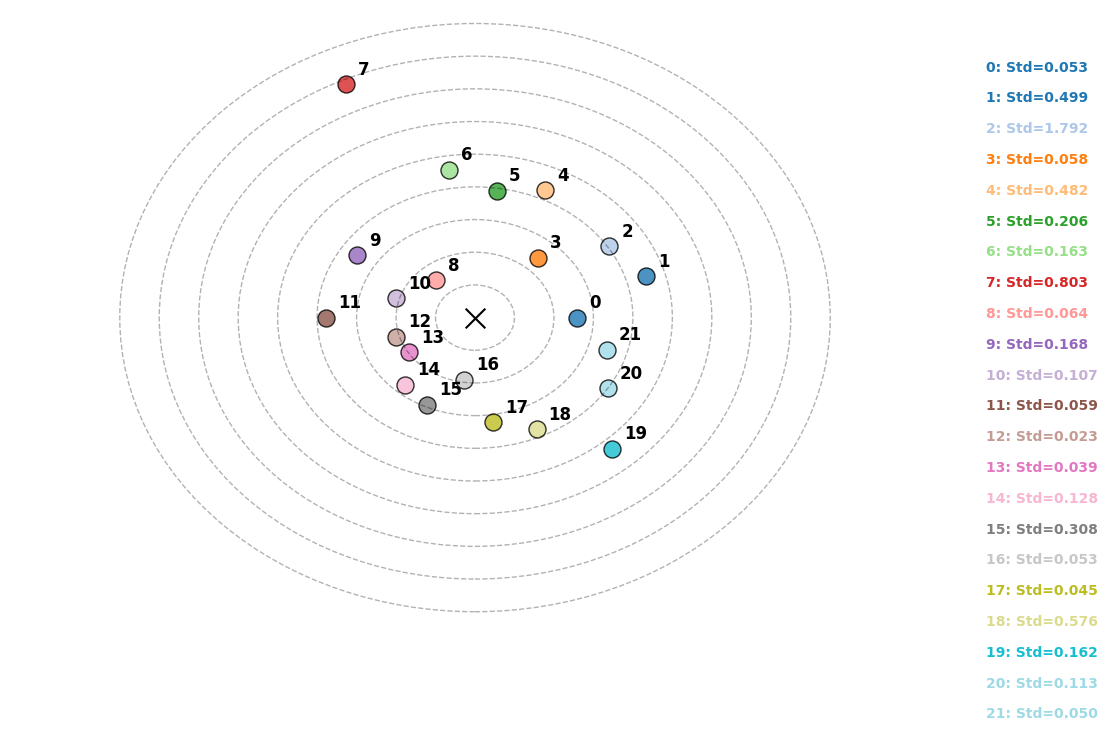

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


devices = summary_df.index.tolist()
distances = summary_df["dist_mean"].values
std_values = summary_df["dist_std"].values
n = len(devices)

# Renk paleti
colors = plt.cm.tab20(np.linspace(0, 1, n))

# Açısal dağılım
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
x = distances * np.cos(angles)
y = distances * np.sin(angles)

plt.figure(figsize=(12, 8))

# Access Point
plt.scatter(0, 0, s=200, color="black", marker="x")

# 2. Döngü: Her cihazı çiz
for i in range(n):
    # Noktayı çiz
    plt.scatter(x[i], y[i], c=[colors[i]], s=150, edgecolors='black', alpha=0.8)

    # HARFİ YAZ: Cihaz ismini (A, B, C...) doğrudan yazdırıyoruz
    # Eğer burada sayı çıkıyorsa, 'devices[i]' yerine 'str(devices[i])' yazarak zorla metin yapabiliriz
    plt.text(x[i] + 0.03, y[i] + 0.03, str(devices[i]),
             fontsize=12, fontweight='bold', color='black')

# Sağ tarafa STD değerlerini listele
y_text_pos = 0.9
for i in range(n):
    label_text = f"{str(devices[i])}: Std={std_values[i]:.3f}"
    plt.text(1.05, y_text_pos, label_text, color=colors[i],
             fontsize=10, fontweight='bold', transform=plt.gca().transAxes)
    y_text_pos -= 0.05

# Mesafe halkaları ve temizlik
max_d = max(distances)
rings = np.arange(0.1, max_d + 0.2, 0.1)
for r in rings:
    circle = plt.Circle((0,0), r, fill=False, linestyle="--", alpha=0.3)
    plt.gca().add_artist(circle)

plt.xlim(-max_d * 1.5, max_d * 1.5)
plt.ylim(-max_d * 1.2, max_d * 1.2)
plt.axis("off")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler


df_clean = burst_df.dropna(subset=features)
X = df_clean[features]
y_true = df_clean["device"]  # Gerçek cihaz etiketleri(Ground Truth)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means Modeli
# Küme sayısı olarak veri setindeki benzersiz cihaz sayısını alıyoruz
k = len(y_true.unique())
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# 4. Adjusted Rand Score ile Kıyasla
ari_score = adjusted_rand_score(y_true, y_pred)

print(f"K-Means ile bulunan küme sayısı (k): {k}")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

K-Means ile bulunan küme sayısı (k): 22
Adjusted Rand Index (ARI): 0.2049


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np

# 1. IE Signature'ları encode et
mlb = MultiLabelBinarizer()
ie_encoded = mlb.fit_transform(burst_df["ie_signature"])
ie_df = pd.DataFrame(ie_encoded, columns=[f"IE_{i}" for i in mlb.classes_])

# 2. Mevcut sayısal özelliklerle birleştir
numerical_features = burst_df[["rssi_median", "rssi_std", "packet_count", "burst_duration"]].reset_index(drop=True)
features_df = pd.concat([numerical_features, ie_df], axis=1)

# 3. Ölçeklendir
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

# 4. K-Means Uygula
k = len(burst_df["device"].unique())
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# 5. ARI Skorunu Ölç
ari_score = adjusted_rand_score(burst_df["device"], y_pred)
print(f"IE Signature eklendikten sonra yeni ARI Skoru: {ari_score:.4f}")

IE Signature eklendikten sonra yeni ARI Skoru: 0.4735


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
import pandas as pd
import numpy as np

numerical_features = burst_df[["rssi_median", "rssi_std", "packet_count", "burst_duration"]].reset_index(drop=True)

# IE Signature (Binarizer)
mlb_ie = MultiLabelBinarizer()
ie_encoded = mlb_ie.fit_transform(burst_df["ie_signature"])
ie_df = pd.DataFrame(ie_encoded, columns=[f"IE_{i}" for i in mlb_ie.classes_])

# Kanallar (Binarizer)
channels_clean = burst_df['channels'].apply(lambda x: x if isinstance(x, list) else [])
mlb_channels = MultiLabelBinarizer()
channels_encoded = mlb_channels.fit_transform(channels_clean)
channels_df = pd.DataFrame(channels_encoded, columns=[f"Ch_{c}" for c in mlb_channels.classes_])

# Tüm özellikleri birleştiriyoruz
X_combined = pd.concat([numerical_features, ie_df, channels_df], axis=1)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# 4. K-Means Gerçek cihaz sayısını biliyoruz
k = len(burst_df["device"].unique())
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

#etiketsiz veri
y_pred = kmeans.fit_predict(X_scaled)

# 5. ARI Skorunu hesapla
y_true = burst_df["device"]
ari_score = adjusted_rand_score(y_true, y_pred)

print(f"K-Means ile bulunan küme sayısı: {k}")
print(f"Elde edilen Adjusted Rand Score (ARI): {ari_score:.4f}")


confusion_matrix = pd.crosstab(y_true, y_pred)
print("\nKarmaşıklık Matrisi") #hangi cihaz hangi kümeye gitti
print(confusion_matrix)

K-Means ile bulunan küme sayısı: 22
Elde edilen Adjusted Rand Score (ARI): 0.3134

Karmaşıklık Matrisi
col_0    0    1    2    3    4    5    6    7    8   9   ...   12   13   14  \
device                                                   ...                  
A         0    0    9    0    0    0    0    2    3   0  ...    0    0    0   
B         0    0    0    1   81    0    0    1    0   0  ...  159    0    0   
C         0    0  506  944    0    0    0  183  668   0  ...    0    0    0   
D         0    0    3    1    0    0    0    1    0   0  ...    0    5    0   
E         0    0    0    3  127   22    0    4    1   0  ...    0    0    0   
G         0    0    0    2    0    1    0    2    0   0  ...    0    0    0   
H         0    0    0    0    0    0   22    0    0   0  ...    0    0    0   
I         0    0    0   36    0    0    0    7   26   0  ...    0    0    0   
J         0    0    0    0    0  108    0    0    1   0  ...    1    0    0   
K         0    0    0    1  

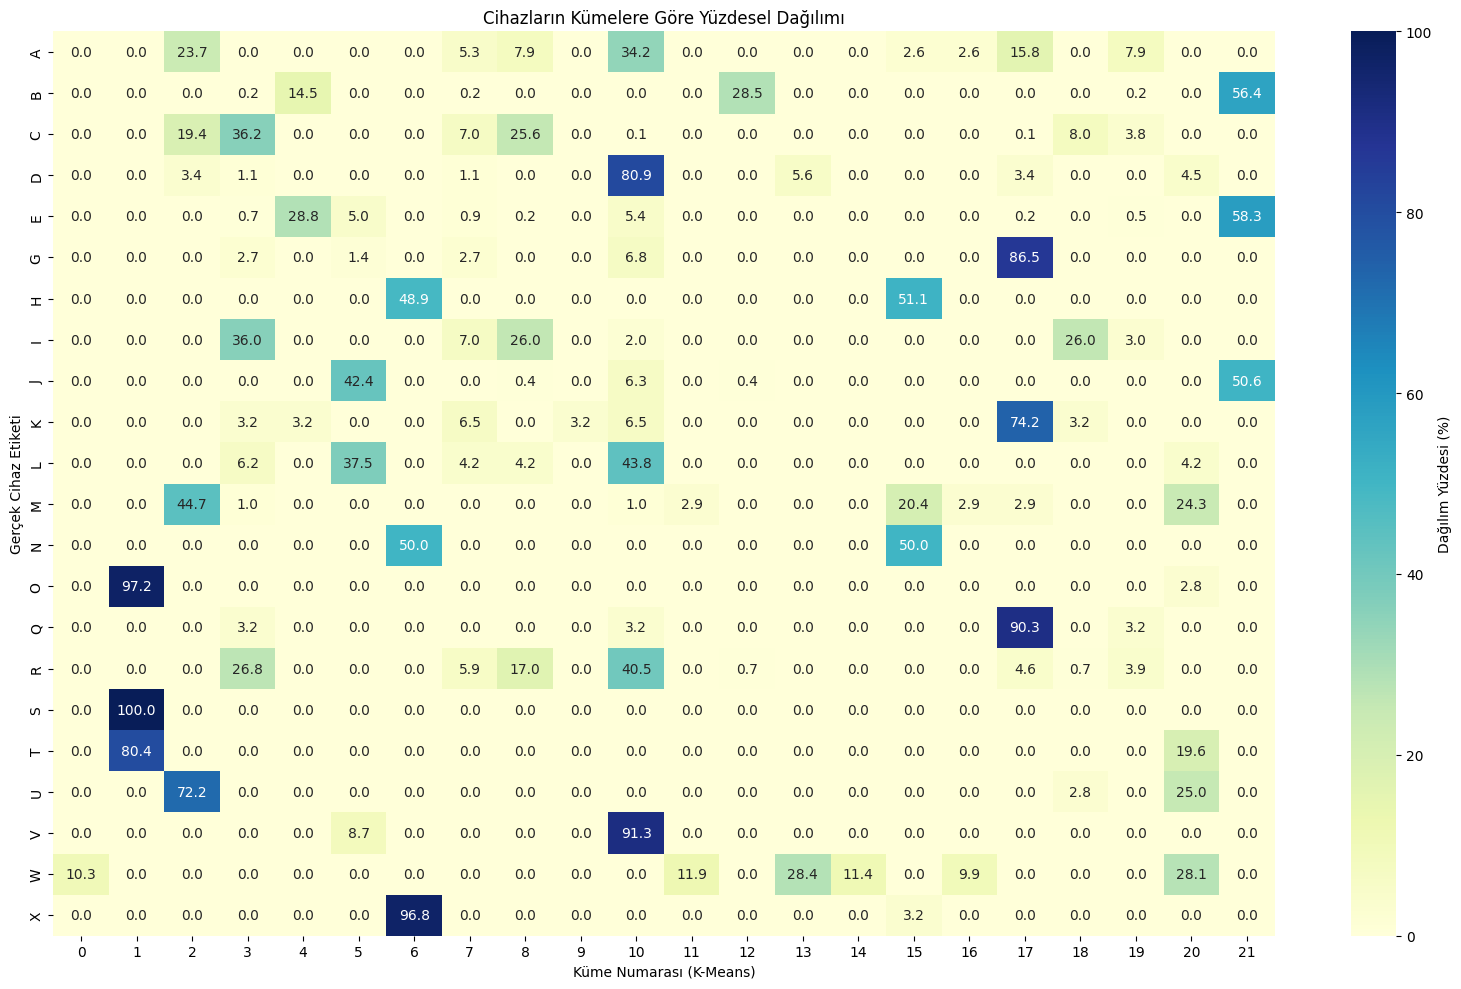

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Karmaşıklık Matrisini (Cihaz vs Küme) oluştur
# 'device' gerçek etiketler, 'y_pred' ise modelin atadığı kümeler
matrix = pd.crosstab(burst_df['device'], y_pred)

# 2. Her satırı (cihazı) kendi toplamına bölerek yüzdelik dağılımı hesapla
matrix_pct = matrix.div(matrix.sum(axis=1), axis=0) * 100

# 3. Isı haritasını (Heatmap) çiz
plt.figure(figsize=(16, 10))
sns.heatmap(matrix_pct, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Dağılım Yüzdesi (%)'})

plt.title("Cihazların Kümelere Göre Yüzdesel Dağılımı")
plt.xlabel("Küme Numarası (K-Means)")
plt.ylabel("Gerçek Cihaz Etiketi")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_combined, burst_df["device"])

importances = rf.feature_importances_
feature_names = X_combined.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print(feature_importance_df.head(20))

           Feature  Importance
3   burst_duration    0.141511
13          IE_255    0.121467
0      rssi_median    0.113898
2     packet_count    0.107550
12          IE_221    0.088321
1         rssi_std    0.061846
9           IE_107    0.055543
10          IE_127    0.052803
7            IE_45    0.037832
6             IE_3    0.028701
19            Ch_6    0.025167
16            Ch_3    0.022083
23           Ch_10    0.018454
11          IE_191    0.016205
21            Ch_8    0.014912
17            Ch_4    0.014731
14            Ch_1    0.013111
24           Ch_11    0.011968
20            Ch_7    0.010810
18            Ch_5    0.010279


In [ ]:
def find_optimal_k(df):

    features = ["rssi_median","rssi_std","packet_count","burst_duration"]

    X = df[features].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    wcss = []

    K_range = range(2,10)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)

    # dirsek noktası
    diffs = np.diff(wcss)
    k_opt = np.argmin(diffs) + 2

    return k_opt

In [ ]:
def run_kmeans(df):

    features = ["rssi_median","rssi_std","packet_count","burst_duration"]

    X = df[features].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k = find_optimal_k(df)

    kmeans = KMeans(n_clusters=k, random_state=42)

    labels = kmeans.fit_predict(X_scaled)

    print("Optimal cluster sayısı:", k)

    return labels

In [ ]:
print("Anechoic Random")
labels1 = run_kmeans(anechoic_random)

print("Anechoic Real")
labels2 = run_kmeans(anechoic_real)

print("Noisy Random")
labels3 = run_kmeans(noisy_random)

print("Noisy Real")
labels4 = run_kmeans(noisy_real)

Anechoic Random
Optimal cluster sayısı: 2
Anechoic Real
Optimal cluster sayısı: 3
Noisy Random
Optimal cluster sayısı: 3
Noisy Real
Optimal cluster sayısı: 3


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
import pandas as pd

def compute_ari_with_optimal_k(df):
    # 1. Özellikleri tanımla (ie_count ve ie_unique sütunlarının df'te olduğunu varsayıyoruz)
    features = ["rssi_median", "rssi_std", "packet_count", "burst_duration", "ie_count", "ie_unique"]
    X = df[features].dropna()
    true_labels = df.loc[X.index, "device"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. Optimum K'yi Siluet Skoru ile bul (Silhouette Analysis)
    best_k = 2
    best_score = -1

    # 2'den, gruptaki gerçek cihaz sayısına kadar tara
    max_k = min(len(true_labels.unique()) + 2, 10)
    for k in range(2, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_k = k

    # 3. Bulunan optimum K ile K-Means'i çalıştır
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # 4. Performansı ARI ile ölç
    ari = adjusted_rand_score(true_labels, cluster_labels)

    return ari, best_k

for group in [anechoic_random, anechoic_real, noisy_random, noisy_real]:
    group["ie_count"] = group["ie_signature"].apply(len)
    group["ie_unique"] = group["ie_signature"].apply(lambda x: len(set(x)))

# Analizi çalıştır
for name, group in [("Anechoic Random", anechoic_random), ("Anechoic Real", anechoic_real),
                    ("Noisy Random", noisy_random), ("Noisy Real", noisy_real)]:
    ari, k = compute_ari_with_optimal_k(group)
    print(f"{name} -> ARI: {ari:.4f} (Bulunan Optimum K: {k})")

/tmp/ipykernel_404/2576607528.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group["ie_count"] = group["ie_signature"].apply(len)
/tmp/ipykernel_404/2576607528.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group["ie_unique"] = group["ie_signature"].apply(lambda x: len(set(x)))


Anechoic Random -> ARI: 0.2565 (Bulunan Optimum K: 5)
Anechoic Real -> ARI: 0.3204 (Bulunan Optimum K: 2)
Noisy Random -> ARI: 0.8241 (Bulunan Optimum K: 9)
Noisy Real -> ARI: 0.6474 (Bulunan Optimum K: 3)


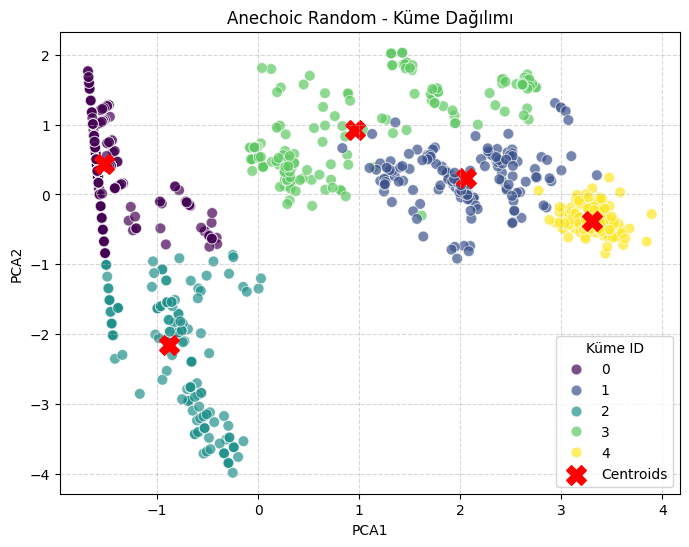

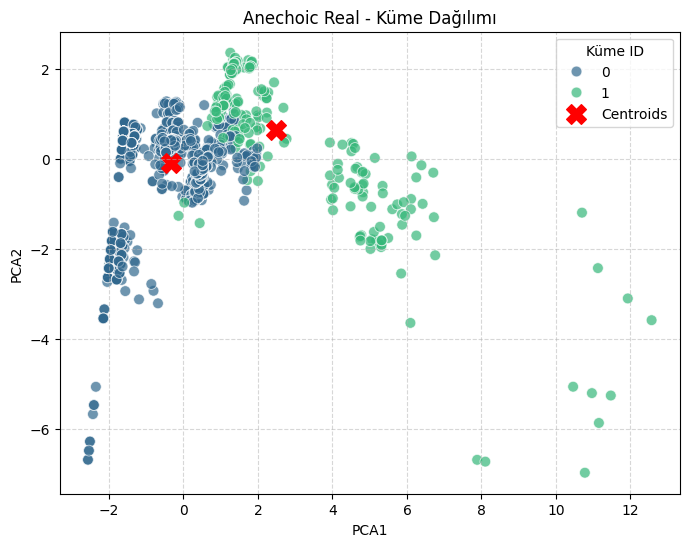

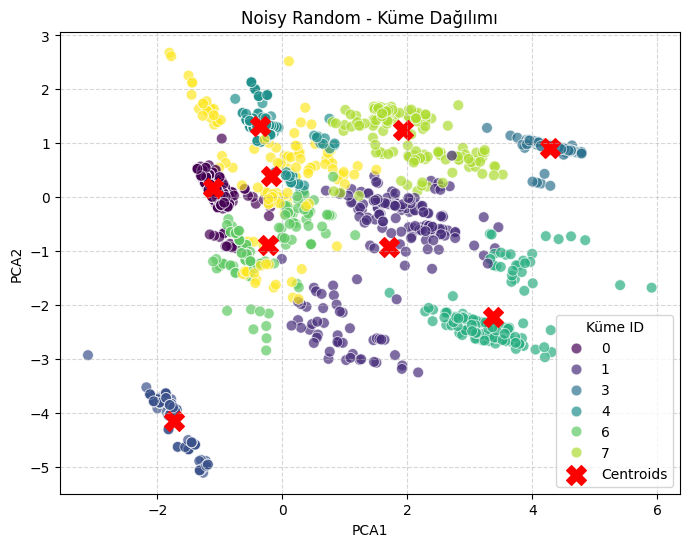

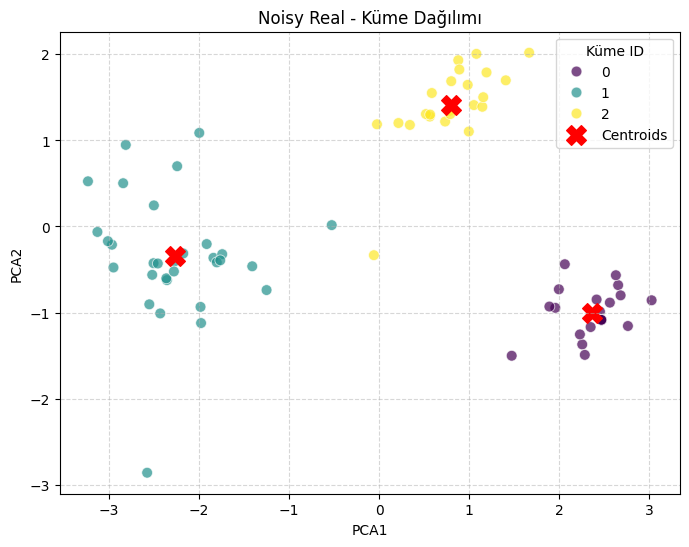

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # Import PCA

def plot_kmeans_clusters(df, group_name, best_k):
    # 1. Özellikler
    features = ["rssi_median", "rssi_std", "packet_count", "burst_duration", "ie_count", "ie_unique"]

    # 2. Veriyi ölçeklendir ve PCA ile 2 boyuta indir (Tüm özellikleri korumak için)
    X = StandardScaler().fit_transform(df[features].dropna())
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # 3. DataFrame oluştur
    plot_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])

    # 4. K-Means (Senin daha önce bulduğun K ile)
    # Burada labels'ı zaten kümeleme yaptığın işlemden gelen 'labels' olarak kullanmalısın
    # Eğer labels elinde yoksa burada yeniden hesaplatıyoruz
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    plot_df["cluster"] = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    # PCA ile merkezleri de 2 boyuta taşı
    centers_pca = pca.transform(centers)

    # 5. Görselleştir
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60, alpha=0.7)
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Centroids')

    plt.title(f"{group_name} - Küme Dağılımı")
    plt.legend(title="Küme ID")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Tüm gruplar için çalıştır
for name, group in [("Anechoic Random", anechoic_random), ("Anechoic Real", anechoic_real),
                    ("Noisy Random", noisy_random), ("Noisy Real", noisy_real)]:
    # Burada 'labels' değişkenini, compute_ari fonksiyonundan gelen kümeleme sonucu ile güncellemelisin
    ari, k = compute_ari_with_optimal_k(group) # Recalculate or retrieve k
    plot_kmeans_clusters(group, name, k)


In [174]:
# Raporu temiz bir şekilde yazdırmak için fonksiyon
def print_summary_report(groups_dict):
    print(f"{'Grup Adı':<20} | {'Gerçek Cihaz':<15} | {'Bulunan K':<10}")
    print("-" * 50)

    for name, group in groups_dict.items():
        # Gerçek cihaz sayısını hesapla
        true_device_count = len(group["device"].unique())

        # Senin fonksiyonunla ARI ve K'yi al
        _, k = compute_ari_with_optimal_k(group)

        # Sonucu yazdır
        print(f"{name:<20} | {true_device_count:<15} | {k:<10}")

# Grupları sözlük yapısında tanımla
groups_dict = {
    "Anechoic Random": anechoic_random,
    "Anechoic Real": anechoic_real,
    "Noisy Random": noisy_random,
    "Noisy Real": noisy_real
}

# Raporu çalıştır
print_summary_report(groups_dict)

Grup Adı             | Gerçek Cihaz    | Bulunan K 
--------------------------------------------------
Anechoic Random      | 6               | 5         
Anechoic Real        | 2               | 2         
Noisy Random         | 12              | 9         
Noisy Real           | 2               | 3         


In [185]:
# burst_df üzerinde filtreleme yapıyoruz
# 'temp_distance' senin kodunda mesafeyi tutan sütun ismi
c_ham_data = burst_df[burst_df["device"] == "C"]

# Mesafeye göre en büyük 10 paketi çek
outliers = c_ham_data.nlargest(10, 'temp_distance')

print("--- C Cihazının En Garip (En Uzak Tahmin Edilen) 10 Paketi ---")
# 'ie_signature' ve 'rssi_median' gibi ham özelliklere doğrudan erişiyoruz
print(outliers[['device', 'temp_distance', 'rssi_median', 'packet_count', 'burst_duration']])

--- C Cihazının En Garip (En Uzak Tahmin Edilen) 10 Paketi ---
     device  temp_distance  rssi_median  packet_count  burst_duration
2721      C      39.810717        -93.0             1             0.0
2942      C      39.810717        -93.0             1             0.0
1795      C      34.145489        -91.0             1             0.0
3463      C      34.145489        -91.0             1             0.0
2586      C      29.286446        -89.0             1             0.0
3046      C      29.286446        -89.0             1             0.0
3198      C      18.478498        -83.0             1             0.0
3512      C      15.848932        -81.0             1             0.0
3526      C      15.848932        -81.0             1             0.0
1733      C      11.659144        -77.0             1             0.0
